# MIDI → music21 → MusicXML → Verovio/MEI diagnostics

This is a **maintainer testing notebook**, not a user tutorial. It compares notation-reconstruction strategies on real MIDI files from `test_corpus/non_mei_test_copora_links.txt` and keeps every intermediate artifact for inspection.

The first known case is ASAP's Bach BWV 846 Prelude. In the lower staff of measure 1, MIDI contains C4 from offset 0 and E4 from offset 1/16. The baseline leaves both overlapping notes unvoiced; MusicXML then has no voice separation and Verovio serializes them into one layer. The expected notation has a second voice containing a 1/16 rest followed by E4. The second case is the BWV 846 Fugue: music21's default `(4, 3)` post-quantization turns adjacent G4/F4 32nds into one 16th-note chord. CAMAT's production grid `(8, 6, 4, 3)` must keep them sequential.

The notebook tests three reconstruction variants on that case and baseline/fixed variants on additional polyphonic and simple MIDI sources. Conversion success is not treated as proof of correct notation.

In [1]:
from pathlib import Path
from urllib.parse import urlparse
import hashlib
import json
import os
import sys
import time
import xml.etree.ElementTree as ET

import music21
from music21 import converter as m21_converter
from music21 import stream as m21_stream
import pandas as pd
from IPython.display import Markdown, display

_here = Path.cwd().resolve()
ROOT = next(
    (path for path in (_here, *_here.parents) if (path / 'camat' / '__init__.py').is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError('Run this notebook from a CAMAT source checkout.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from camat import (
    __version__ as camat_version,
    expand_file_sources,
    parse_files,
    vrv_convert_to_mei,
    vrv_display_svg,
    vrv_get_toolkit,
    vrv_load_from_file,
    vrv_quiet,
    vrv_render_page,
    vrv_set_options,
)
from camat.music_utils import get_file_path
from camat.conversion import _load_music21_score, _prepare_midi_score_for_export

MANIFEST = ROOT / 'test_corpus' / 'non_mei_test_copora_links.txt'
OUTPUT_DIR = ROOT / 'converted_mei' / 'midi_conversion_tests'
SOURCE_DIR = OUTPUT_DIR / '_sources'
MUSICXML_DIR = OUTPUT_DIR / 'musicxml'
MEI_DIR = OUTPUT_DIR / 'mei'
for directory in (OUTPUT_DIR, SOURCE_DIR, MUSICXML_DIR, MEI_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RUN_NETWORK_EXAMPLES = os.environ.get('CAMAT_RUN_NETWORK_EXAMPLES', '1').lower() not in {'0', 'false', 'no'}
RUN_EXTENDED_CASES = os.environ.get('CAMAT_RUN_EXTENDED_MIDI_CASES', '0').lower() in {'1', 'true', 'yes'}

with vrv_quiet():
    verovio_version = vrv_get_toolkit().getVersion()
print('CAMAT:', camat_version)
print('music21:', music21.__version__)
print('Verovio:', verovio_version)
print('Output:', OUTPUT_DIR)
print('Extended cases:', RUN_EXTENDED_CASES)

CAMAT: 0.1.13
music21: 10.5.0
Verovio: 6.2.1-8d42439
Output: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/midi_conversion_tests
Extended cases: False


## Corpus cases and variants

Core cases cover the known delayed bass voice, a fugue, a simpler melody-plus-chords file, and a denser Beethoven piano movement. Set `CAMAT_RUN_EXTENDED_MIDI_CASES=1` before starting Jupyter to add Chopin and Mozart.

Variants:

- `baseline`: music21 defaults, `converter.parse(...)` followed by `Score.makeNotation(...)`;
- `voices_no_gap_rests`: separate overlapping notes with `Measure.makeVoices(fillGaps=False)`; music21 later exports hidden gap-filling MusicXML rests, which Verovio represents as MEI `<space>`;
- `voices_with_gap_rests`: CAMAT production behavior: import with the `(8, 6, 4, 3)` quantization grid, separate overlaps, and materialize visible leading/trailing rests with `fillGaps=True`.

In [2]:
all_sources = expand_file_sources([str(MANIFEST)], base_dir=ROOT, verbose=False)

def select_source(fragment):
    return next(source for source in all_sources if fragment in source)

VARIANT_SPECS = {
    'baseline': {'make_voices': False, 'fill_gaps': None},
    'voices_no_gap_rests': {'make_voices': True, 'fill_gaps': False},
    'voices_with_gap_rests': {'make_voices': True, 'fill_gaps': True},
}

CORE_CASES = [
    {
        'case_id': 'bwv846_prelude',
        'source': select_source('Bach/Prelude/bwv_846/midi_score.mid'),
        'variants': list(VARIANT_SPECS),
        'focus': 'measure 1, lower staff: delayed E4 voice',
    },
    {
        'case_id': 'bwv846_fugue',
        'source': select_source('Bach/Fugue/bwv_846/midi_score.mid'),
        'variants': ['baseline', 'voices_with_gap_rests'],
        'focus': 'measure 1 G4/F4 sequential 32nds and contrapuntal voices',
    },
    {
        'case_id': 'playford1',
        'source': select_source('MIDI/playford1.mid'),
        'variants': ['baseline', 'voices_with_gap_rests'],
        'focus': 'simple melody and chord accompaniment',
    },
    {
        'case_id': 'beethoven_op13_mvt1',
        'source': select_source('Beethoven/Piano_Sonatas/8-1/midi_score.mid'),
        'variants': ['baseline', 'voices_with_gap_rests'],
        'focus': 'dense piano texture',
    },
]
EXTENDED_CASES = [
    {
        'case_id': 'chopin_ballade1',
        'source': select_source('Chopin/Ballades/1/midi_score.mid'),
        'variants': ['baseline', 'voices_with_gap_rests'],
        'focus': 'large-form piano texture',
    },
    {
        'case_id': 'mozart_fantasie_k475',
        'source': select_source('Mozart/Fantasie_475/midi_score.mid'),
        'variants': ['baseline', 'voices_with_gap_rests'],
        'focus': 'changing keyboard texture',
    },
]
CASE_SPECS = CORE_CASES + (EXTENDED_CASES if RUN_EXTENDED_CASES else [])
display(pd.DataFrame(CASE_SPECS))

,case_id,source,variants,focus
0,bwv846_prelude,https://raw.githubusercontent.com/fosfrancesco...,"[baseline, voices_no_gap_rests, voices_with_ga...","measure 1, lower staff: delayed E4 voice"
1,bwv846_fugue,https://raw.githubusercontent.com/fosfrancesco...,"[baseline, voices_with_gap_rests]",measure 1 G4/F4 sequential 32nds and contrapun...
2,playford1,https://raw.githubusercontent.com/jukedeck/not...,"[baseline, voices_with_gap_rests]",simple melody and chord accompaniment
3,beethoven_op13_mvt1,https://raw.githubusercontent.com/fosfrancesco...,"[baseline, voices_with_gap_rests]",dense piano texture


## Detect unvoiced overlaps before export

MIDI stores timed note events, not notated voices or rests. The diagnostic below finds staggered overlaps inside each music21 measure. Simultaneous chord tones are not counted; a later note beginning before an earlier one ends is.

In [3]:
def local_name(tag):
    return tag.rsplit('}', 1)[-1] if '}' in tag else tag

def pitch_label(element):
    if getattr(element, 'isRest', False):
        return 'rest'
    if getattr(element, 'isChord', False):
        return ' '.join(pitch.nameWithOctave for pitch in element.pitches)
    return getattr(element, 'nameWithOctave', type(element).__name__)

def staggered_overlap_pairs(measure):
    events = []
    for element in measure.recurse().notes:
        start = float(element.getOffsetInHierarchy(measure))
        end = start + float(element.quarterLength)
        events.append((start, end, pitch_label(element)))
    events.sort()
    pairs = []
    for index, left in enumerate(events):
        for right in events[index + 1:]:
            if right[0] >= left[1] - 1e-9:
                break
            if right[0] > left[0] + 1e-9:
                pairs.append((left, right))
    return pairs

def score_structure_summary(score):
    measures = [
        measure
        for part in score.parts
        for measure in part.getElementsByClass(m21_stream.Measure)
    ]
    overlap_measures = [measure for measure in measures if staggered_overlap_pairs(measure)]
    return {
        'parts': len(score.parts),
        'notes': len(score.recurse().notes),
        'measures': len(measures),
        'staggered_overlap_measures': len(overlap_measures),
        'measures_with_voices': sum(bool(measure.voices) for measure in measures),
    }

def apply_variant(score, variant_name):
    if variant_name == 'voices_with_gap_rests':
        _prepare_midi_score_for_export(score)
        return score
    variant = VARIANT_SPECS[variant_name]
    if variant['make_voices']:
        for part in score.parts:
            for measure in part.getElementsByClass(m21_stream.Measure):
                if staggered_overlap_pairs(measure):
                    measure.makeVoices(
                        inPlace=True,
                        fillGaps=variant['fill_gaps'],
                    )
    score.makeNotation(inPlace=True)
    return score

In [4]:
XML_ID = '{http://www.w3.org/XML/1998/namespace}id'

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

def mei_stats(path):
    root = ET.parse(path).getroot()
    elements = list(root.iter())
    ids = [element.attrib[XML_ID] for element in elements if XML_ID in element.attrib]
    return {
        'mei_notes': sum(local_name(element.tag) == 'note' for element in elements),
        'mei_rests': sum(local_name(element.tag) in {'rest', 'mRest', 'multiRest'} for element in elements),
        'mei_spaces': sum(local_name(element.tag) == 'space' for element in elements),
        'mei_layers': sum(local_name(element.tag) == 'layer' for element in elements),
        'duplicate_xml_ids': len(ids) - len(set(ids)),
    }

def convert_case_variant(case, variant_name, local_midi_path):
    started = time.perf_counter()
    record = {
        'case_id': case['case_id'],
        'variant': variant_name,
        'source': case['source'],
        'local_midi': str(local_midi_path),
        'focus': case['focus'],
        'status': 'fail',
        'error': None,
    }
    try:
        if variant_name == 'voices_with_gap_rests':
            score, import_diagnostics = _load_music21_score(Path(local_midi_path))
        else:
            score = m21_converter.parse(str(local_midi_path))
            import_diagnostics = {'quantization_quarter_length_divisors': [4, 3]}
        before = score_structure_summary(score)
        apply_variant(score, variant_name)
        after = score_structure_summary(score)

        musicxml_path = MUSICXML_DIR / f"{case['case_id']}__{variant_name}.musicxml"
        written = score.write('musicxml', fp=str(musicxml_path))
        musicxml_path = Path(written) if written else musicxml_path

        with vrv_quiet():
            vrv_set_options(
                breaks='auto',
                removeIds=False,
                xmlIdSeed=0,
            )
            mei_text = vrv_convert_to_mei(str(musicxml_path))
        mei_path = MEI_DIR / f"{case['case_id']}__{variant_name}.mei"
        mei_path.write_text(mei_text, encoding='utf-8')

        record.update({
            'status': 'ok',
            'musicxml': str(musicxml_path),
            'mei': str(mei_path),
            'midi_sha256': file_sha256(local_midi_path),
            'musicxml_sha256': file_sha256(musicxml_path),
            'mei_sha256': file_sha256(mei_path),
            'musicxml_bytes': musicxml_path.stat().st_size,
            'mei_bytes': mei_path.stat().st_size,
            'overlap_measures_before': before['staggered_overlap_measures'],
            'voice_measures_before': before['measures_with_voices'],
            'voice_measures_after': after['measures_with_voices'],
            **import_diagnostics,
            **mei_stats(mei_path),
        })
        return record, score
    except Exception as exc:
        record['error'] = f'{type(exc).__name__}: {exc}'
        return record, None
    finally:
        record['conversion_seconds'] = round(time.perf_counter() - started, 3)

## Run the conversion matrix

Each variant reparses the same downloaded MIDI from scratch. This avoids state leaking from one music21 transformation into another. Failures are isolated in the report so one case does not stop the matrix.

In [5]:
records = []
scores = {}
if not RUN_NETWORK_EXAMPLES:
    print('Skipped: CAMAT_RUN_NETWORK_EXAMPLES=0')
else:
    for case in CASE_SPECS:
        try:
            local_midi_path = Path(get_file_path(
                case['source'],
                timeout_seconds=90,
                use_cache=True,
                cache_dir=str(SOURCE_DIR),
            ))
        except Exception as exc:
            records.append({
                'case_id': case['case_id'],
                'variant': '(download)',
                'source': case['source'],
                'status': 'fail',
                'error': f'{type(exc).__name__}: {exc}',
            })
            continue

        for variant_name in case['variants']:
            record, score = convert_case_variant(case, variant_name, local_midi_path)
            records.append(record)
            if score is not None:
                scores[(case['case_id'], variant_name)] = score

    def add_parse_metrics(record, result):
        df_pitch = result['df_pitch']
        record['camat_parse_status'] = 'ok'
        record['camat_pitch_rows'] = len(df_pitch)
        record['camat_event_rows'] = len(result['df_events'])
        record['camat_voice_labels'] = int(df_pitch['Voice'].nunique(dropna=True))

    successful_records = [record for record in records if record.get('status') == 'ok']
    try:
        parsed_results, _, _ = parse_files(
            [record['mei'] for record in successful_records],
            backend='none',
            display_preview_df_pitch=False,
            display_preview_df_events=False,
            include_xml_ids=True,
            show_progress=False,
            quiet_native_warnings=True,
        )
        for record, result in zip(successful_records, parsed_results):
            add_parse_metrics(record, result)
    except Exception as batch_exc:
        print(f'Batch CAMAT parse failed; retrying individually: {batch_exc}')
        for record in successful_records:
            try:
                parsed, _, _ = parse_files(
                    [record['mei']],
                    backend='none',
                    display_preview_df_pitch=False,
                    display_preview_df_events=False,
                    include_xml_ids=True,
                    show_progress=False,
                    quiet_native_warnings=True,
                )
                add_parse_metrics(record, parsed[0])
            except Exception as exc:
                record['camat_parse_status'] = 'fail'
                record['camat_parse_error'] = f'{type(exc).__name__}: {exc}'

report_df = pd.DataFrame(records)
report_columns = [
    'case_id', 'variant', 'status', 'overlap_measures_before',
    'voice_measures_after', 'quantization_quarter_length_divisors',
    'mei_notes', 'mei_rests', 'mei_spaces', 'mei_layers',
    'camat_pitch_rows', 'camat_voice_labels', 'conversion_seconds', 'error',
]
display(report_df.reindex(columns=report_columns))

report_path = OUTPUT_DIR / 'midi_conversion_report.json'
report_path.write_text(json.dumps(records, indent=2), encoding='utf-8')
print('Report:', report_path)

Processing (verovio): bwv846_prelude__baseline.mei -> 00_bwv846_prelude_baseline
Extracted non-barline MEI events: 42 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'tempo'].

Processing (verovio): bwv846_prelude__voices_no_gap_rests.mei -> 01_bwv846_prelude_voices_no_gap_rests


Extracted non-barline MEI events: 108 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'space', 'tempo'].

Processing (verovio): bwv846_prelude__voices_with_gap_rests.mei -> 02_bwv846_prelude_voices_with_gap_rests
Extracted non-barline MEI events: 42 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'tempo'].



Processing (verovio): bwv846_fugue__baseline.mei -> 03_bwv846_fugue_baseline


Extracted non-barline MEI events: 59 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'mrest', 'tempo', 'tie'].

Processing (verovio): bwv846_fugue__voices_with_gap_rests.mei -> 04_bwv846_fugue_voices_with_gap_rests


Extracted non-barline MEI events: 58 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'mrest', 'tempo', 'tie'].

Processing (verovio): playford1__baseline.mei -> 05_playford1_baseline
Extracted non-barline MEI events: 40 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'mrest'].

Processing (verovio): playford1__voices_with_gap_rests.mei -> 06_playford1_voices_with_gap_rests


Extracted non-barline MEI events: 40 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'mrest'].

Processing (verovio): beethoven_op13_mvt1__baseline.mei -> 07_beethoven_op13_mvt1_baseline


Extracted non-barline MEI events: 380 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'mrest', 'tempo', 'tie'].

Processing (verovio): beethoven_op13_mvt1__voices_with_gap_rests.mei -> 08_beethoven_op13_mvt1_voices_with_gap_rests


Extracted non-barline MEI events: 415 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'mrest', 'tempo', 'tie'].


,case_id,variant,status,overlap_measures_before,voice_measures_after,quantization_quarter_length_divisors,mei_notes,mei_rests,mei_spaces,mei_layers,camat_pitch_rows,camat_voice_labels,conversion_seconds,error
0,bwv846_prelude,baseline,ok,34,0,"[4, 3]",549,66,0,70,549,2,0.360,None
1,bwv846_prelude,voices_no_gap_rests,ok,34,34,"[4, 3]",549,66,66,104,549,3,0.381,None
2,bwv846_prelude,voices_with_gap_rests,ok,34,34,"[8, 6, 4, 3]",549,132,0,104,549,3,0.632,None
3,bwv846_fugue,baseline,ok,42,40,"[4, 3]",785,112,0,94,755,4,0.550,None
4,bwv846_fugue,voices_with_gap_rests,ok,44,45,"[8, 6, 4, 3]",783,92,0,102,755,5,0.929,None
5,playford1,baseline,ok,0,0,"[4, 3]",222,3,0,66,222,2,0.180,None
6,playford1,voices_with_gap_rests,ok,0,0,"[8, 6, 4, 3]",222,3,0,66,222,2,0.223,None
7,beethoven_op13_mvt1,baseline,ok,154,155,"[4, 3]",4711,757,0,774,4659,4,3.433,None
8,beethoven_op13_mvt1,voices_with_gap_rests,ok,160,167,"[8, 6, 4, 3]",4782,798,0,786,4651,4,5.175,None


Report: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/midi_conversion_tests/midi_conversion_report.json


## Known case: music21 measure structure

The table should make the bug boundary explicit:

- baseline: C4 and E4 overlap in `unvoiced`;
- no-gap variant: E4 moves to voice 2; the music21 stream has no rest, so export later supplies a hidden rest/MEI space;
- filled-gap variant: voice 2 begins with a 0.25-quarter-length rest (a sixteenth), then E4 at offset 0.25.

In [6]:
def measure_event_rows(score, *, part_index, measure_number, variant):
    measure = score.parts[part_index].measure(measure_number)
    rows = []
    for position, element in enumerate(measure.recurse().notesAndRests):
        voice = element.getContextByClass(m21_stream.Voice)
        rows.append({
            'variant': variant,
            'position': position,
            'voice': str(voice.id) if voice is not None else 'unvoiced',
            'offset_ql': float(element.getOffsetInHierarchy(measure)),
            'duration_ql': float(element.quarterLength),
            'event': pitch_label(element),
        })
    return rows

known_rows = []
for variant_name in VARIANT_SPECS:
    score = scores.get(('bwv846_prelude', variant_name))
    if score is not None:
        known_rows.extend(measure_event_rows(
            score,
            part_index=1,
            measure_number=1,
            variant=variant_name,
        ))
known_m21_df = pd.DataFrame(known_rows)
display(known_m21_df)

def has_expected_delayed_e_voice(score):
    measure = score.parts[1].measure(1)
    for voice in measure.voices:
        events = list(voice.notesAndRests)
        has_rest = any(
            event.isRest
            and abs(float(event.offset)) < 1e-9
            and abs(float(event.quarterLength) - 0.25) < 1e-9
            for event in events
        )
        has_e = any(
            getattr(event, 'nameWithOctave', None) == 'E4'
            and abs(float(event.offset) - 0.25) < 1e-9
            for event in events
        )
        if has_rest and has_e:
            return True
    return False

known_checks = []
for variant_name in VARIANT_SPECS:
    score = scores.get(('bwv846_prelude', variant_name))
    if score is not None:
        known_checks.append({
            'variant': variant_name,
            'has_expected_rest_then_e_voice': has_expected_delayed_e_voice(score),
        })
display(pd.DataFrame(known_checks))

,variant,position,voice,offset_ql,duration_ql,event
0,baseline,0,unvoiced,0.00,2.00,C4
1,baseline,1,unvoiced,0.25,1.75,E4
2,baseline,2,unvoiced,2.00,2.00,C4
3,baseline,3,unvoiced,2.25,1.75,E4
4,voices_no_gap_rests,0,140483923700976,0.00,2.00,C4
5,voices_no_gap_rests,1,140483923700976,2.00,2.00,C4
6,voices_no_gap_rests,2,140481097671504,0.25,1.75,E4
7,voices_no_gap_rests,3,140481097671504,2.25,1.75,E4
8,voices_with_gap_rests,0,140480013696560,0.00,2.00,C4
9,voices_with_gap_rests,1,140480013696560,2.00,2.00,C4


,variant,has_expected_rest_then_e_voice
0,baseline,False
1,voices_no_gap_rests,False
2,voices_with_gap_rests,True


In [7]:
def musicxml_measure_rows(path, *, part_number=2, measure_number='1', variant=''):
    root = ET.parse(path).getroot()
    part = root.findall('part')[part_number - 1]
    measure = next(item for item in part.findall('measure') if item.get('number') == measure_number)
    divisions_text = measure.findtext('./attributes/divisions')
    divisions = float(divisions_text) if divisions_text else 1.0
    rows = []
    for position, note_element in enumerate(measure.findall('note')):
        rest = note_element.find('rest') is not None
        if rest:
            pitch = 'rest'
        else:
            step = note_element.findtext('./pitch/step') or ''
            octave = note_element.findtext('./pitch/octave') or ''
            pitch = f'{step}{octave}'
        duration = float(note_element.findtext('duration') or 0)
        rows.append({
            'variant': variant,
            'position': position,
            'voice': note_element.findtext('voice') or '(none)',
            'event': pitch,
            'duration_ql': duration / divisions,
            'type': note_element.findtext('type'),
            'dots': len(note_element.findall('dot')),
            'print_object': note_element.get('print-object', 'yes'),
        })
    return rows

def mei_measure_rows(path, *, staff_number='2', measure_number='1', variant=''):
    root = ET.parse(path).getroot()
    measure = next(
        element for element in root.iter()
        if local_name(element.tag) == 'measure' and element.get('n') == measure_number
    )
    staff = next(
        element for element in measure
        if local_name(element.tag) == 'staff' and element.get('n') == staff_number
    )
    rows = []
    for layer in staff:
        if local_name(layer.tag) != 'layer':
            continue
        position = 0
        for element in layer.iter():
            name = local_name(element.tag)
            if name not in {'note', 'rest', 'mRest', 'multiRest', 'space'}:
                continue
            pitch = (
                f"{(element.get('pname') or '').upper()}{element.get('oct') or ''}"
                if name == 'note' else name
            )
            rows.append({
                'variant': variant,
                'layer': layer.get('n'),
                'position': position,
                'event': pitch,
                'dur': element.get('dur'),
                'dots': element.get('dots'),
                'dur_ppq': element.get('dur.ppq'),
            })
            position += 1
    return rows

## Known case: MusicXML voices and MEI layers

This comparison locates the first stage where the intended rest/voice disappears. Both voice variants acquire MusicXML voice 2, but the no-gap export marks its synthesized sixteenth rest `print-object="no"` and Verovio emits `<space>`. The filled-gap variant should retain a visible MEI `<rest dur="16">` in layer 2.

In [8]:
known_records = {
    record['variant']: record
    for record in records
    if record.get('case_id') == 'bwv846_prelude' and record.get('status') == 'ok'
}
musicxml_rows = []
mei_rows = []
for variant_name, record in known_records.items():
    musicxml_rows.extend(musicxml_measure_rows(
        record['musicxml'],
        variant=variant_name,
    ))
    mei_rows.extend(mei_measure_rows(
        record['mei'],
        variant=variant_name,
    ))
musicxml_known_df = pd.DataFrame(musicxml_rows)
mei_known_df = pd.DataFrame(mei_rows)
display(Markdown('### MusicXML, part 2 / measure 1'))
display(musicxml_known_df)
display(Markdown('### MEI, staff 2 / measure 1'))
display(mei_known_df)

stage_checks = []
for variant_name in VARIANT_SPECS:
    xml_variant = musicxml_known_df[musicxml_known_df['variant'] == variant_name]
    mei_variant = mei_known_df[mei_known_df['variant'] == variant_name]
    xml_gap = xml_variant[(xml_variant['voice'] == '2') & (xml_variant['event'] == 'rest')]
    mei_layer_two = mei_variant[mei_variant['layer'] == '2']
    stage_checks.append({
        'variant': variant_name,
        'musicxml_voice_count': xml_variant['voice'].nunique(),
        'musicxml_gap': (
            'none' if xml_gap.empty
            else 'visible rest' if (xml_gap['print_object'] == 'yes').all()
            else 'hidden rest'
        ),
        'mei_layer_count': mei_variant['layer'].nunique(),
        'mei_layer_2_first_event': (
            mei_layer_two.iloc[0]['event'] if not mei_layer_two.empty else 'none'
        ),
    })
display(Markdown('### Stage-boundary check'))
display(pd.DataFrame(stage_checks))

### MusicXML, part 2 / measure 1

,variant,position,voice,event,duration_ql,type,dots,print_object
0,baseline,0,(none),C4,2.00,half,0,yes
1,baseline,1,(none),E4,1.75,quarter,2,yes
2,baseline,2,(none),C4,2.00,half,0,yes
3,baseline,3,(none),E4,1.75,quarter,2,yes
4,voices_no_gap_rests,0,1,C4,2.00,half,0,yes
5,voices_no_gap_rests,1,1,C4,2.00,half,0,yes
6,voices_no_gap_rests,2,2,rest,0.25,16th,0,no
7,voices_no_gap_rests,3,2,E4,1.75,quarter,2,yes
8,voices_no_gap_rests,4,2,rest,0.25,16th,0,no
9,voices_no_gap_rests,5,2,E4,1.75,quarter,2,yes


### MEI, staff 2 / measure 1

,variant,layer,position,event,dur,dots,dur_ppq
0,baseline,1,0,C4,2,NaN,20160
1,baseline,1,1,E4,4,2,17640
2,baseline,1,2,C4,2,NaN,20160
3,baseline,1,3,E4,4,2,17640
4,voices_no_gap_rests,1,0,C4,2,NaN,20160
5,voices_no_gap_rests,1,1,C4,2,NaN,20160
6,voices_no_gap_rests,2,0,space,16,NaN,2520
7,voices_no_gap_rests,2,1,E4,4,2,17640
8,voices_no_gap_rests,2,2,space,16,NaN,2520
9,voices_no_gap_rests,2,3,E4,4,2,17640


### Stage-boundary check

,variant,musicxml_voice_count,musicxml_gap,mei_layer_count,mei_layer_2_first_event
0,baseline,1,none,1,none
1,voices_no_gap_rests,2,hidden rest,2,space
2,voices_with_gap_rests,2,visible rest,2,rest


## Render the three BWV 846 variants

The structural tables are the primary evidence; these page-one renders support visual review. Look especially at measure 1 in the lower staff.

### baseline

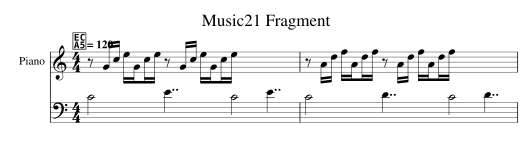

### voices_no_gap_rests

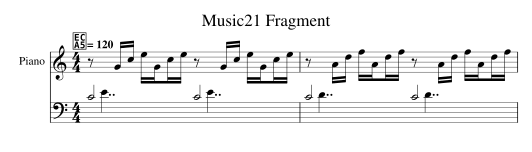

### voices_with_gap_rests

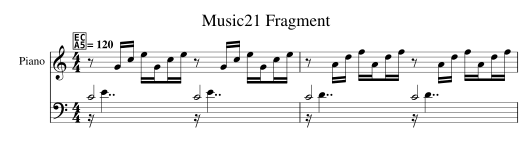

In [9]:
for variant_name in VARIANT_SPECS:
    record = known_records.get(variant_name)
    if record is None:
        continue
    display(Markdown(f'### {variant_name}'))
    with vrv_quiet():
        vrv_set_options(
            pageWidth=1900,
            pageHeight=900,
            scale=28,
            breaks='auto',
            removeIds=False,
        )
        vrv_load_from_file(record['mei'], input_from='mei')
        svg = vrv_render_page(1)
    vrv_display_svg(svg)

## BWV 846 Fugue: 32nd-note quantization boundary

Measure 1 should contain G4 at quarter-length offset 2.75 followed by F4 at 2.875, each lasting 0.125 quarter lengths (a 32nd). The default music21 grid has no eighth-quarter subdivision, so it collapses them into a G4/F4 chord of duration 0.25. The production variant uses CAMAT's `(8, 6, 4, 3)` grid and must preserve two events.

In [10]:
fugue_rows = []
for variant_name in ('baseline', 'voices_with_gap_rests'):
    score = scores.get(('bwv846_fugue', variant_name))
    if score is None:
        continue
    measure = score.parts[0].measure(1)
    for element in measure.flatten().notes:
        offset = float(element.offset)
        if 2.7 <= offset < 3.0:
            fugue_rows.append({
                'variant': variant_name,
                'offset_ql': offset,
                'duration_ql': float(element.quarterLength),
                'event': pitch_label(element),
            })
fugue_quantization_df = pd.DataFrame(fugue_rows)
display(fugue_quantization_df)

production_events = [
    (row.event, row.offset_ql, row.duration_ql)
    for row in fugue_quantization_df.itertuples()
    if row.variant == 'voices_with_gap_rests'
]
fugue_32nds_preserved = production_events == [
    ('G4', 2.75, 0.125),
    ('F4', 2.875, 0.125),
]
display(pd.DataFrame([{
    'production_sequential_g_f_32nds': fugue_32nds_preserved,
    'expected': [('G4', 2.75, 0.125), ('F4', 2.875, 0.125)],
    'actual': production_events,
}]))
if RUN_NETWORK_EXAMPLES:
    assert fugue_32nds_preserved

,variant,offset_ql,duration_ql,event
0,baseline,2.750,0.250,G4 F4
1,voices_with_gap_rests,2.750,0.125,G4
2,voices_with_gap_rests,2.875,0.125,F4


,production_sequential_g_f_32nds,expected,actual
0,True,"[(G4, 2.75, 0.125), (F4, 2.875, 0.125)]","[(G4, 2.75, 0.125), (F4, 2.875, 0.125)]"


## Production-variant review gallery

The Fugue is rendered in both baseline and production form so the opening G/F ornament can be compared directly. Other cases show the `voices_with_gap_rests` production path, which now calls both CAMAT's MIDI import policy and notation-preparation helper. The Prelude is already shown above.

### bwv846_fugue / baseline — measure 1 G4/F4 sequential 32nds and contrapuntal voices

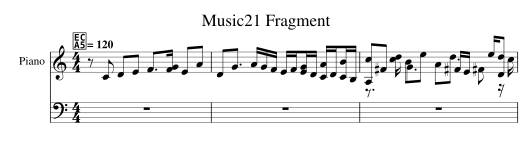

### bwv846_fugue / voices_with_gap_rests — measure 1 G4/F4 sequential 32nds and contrapuntal voices

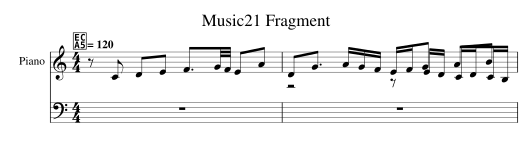

### playford1 / voices_with_gap_rests — simple melody and chord accompaniment

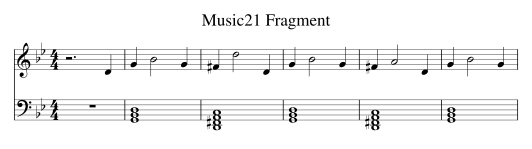

### beethoven_op13_mvt1 / voices_with_gap_rests — dense piano texture

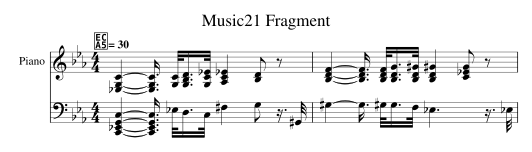

In [11]:
for case in CASE_SPECS:
    if case['case_id'] == 'bwv846_prelude':
        continue
    variants_to_render = (
        ['baseline', 'voices_with_gap_rests']
        if case['case_id'] == 'bwv846_fugue'
        else ['voices_with_gap_rests']
    )
    for variant_name in variants_to_render:
        record = next((
            item for item in records
            if item.get('case_id') == case['case_id']
            and item.get('variant') == variant_name
            and item.get('status') == 'ok'
        ), None)
        if record is None:
            continue
        display(Markdown(f"### {case['case_id']} / {variant_name} — {case['focus']}"))
        with vrv_quiet():
            vrv_set_options(
                pageWidth=1900,
                pageHeight=900,
                scale=28,
                breaks='auto',
                removeIds=False,
            )
            vrv_load_from_file(record['mei'], input_from='mei')
            svg = vrv_render_page(1)
        vrv_display_svg(svg)

## Cross-case change summary

Deltas are relative to each case's baseline. An unchanged simple case is useful evidence that the heuristic is inactive when no staggered overlaps are present; changed counts identify cases that need visual review rather than automatically indicating improvement. Exact hashes can still differ after a no-op because fresh music21 imports generate new internal/part identifiers. CAMAT pitch rows can be fewer than MEI `<note>` elements because tied segments may be consolidated.

In [12]:
delta_metrics = [
    'voice_measures_after', 'mei_rests', 'mei_spaces', 'mei_layers',
    'camat_pitch_rows', 'camat_voice_labels',
]
delta_rows = []
successful_records = [record for record in records if record.get('status') == 'ok']
for case in CASE_SPECS:
    case_records = [record for record in successful_records if record['case_id'] == case['case_id']]
    baseline = next((record for record in case_records if record['variant'] == 'baseline'), None)
    if baseline is None:
        continue
    for record in case_records:
        row = {
            'case_id': case['case_id'],
            'variant': record['variant'],
            'same_musicxml_as_baseline': record['musicxml_sha256'] == baseline['musicxml_sha256'],
            'same_mei_as_baseline': record['mei_sha256'] == baseline['mei_sha256'],
        }
        for metric in delta_metrics:
            row[f'delta_{metric}'] = (record.get(metric) or 0) - (baseline.get(metric) or 0)
        delta_rows.append(row)
display(pd.DataFrame(delta_rows))

,case_id,variant,same_musicxml_as_baseline,same_mei_as_baseline,delta_voice_measures_after,delta_mei_rests,delta_mei_spaces,delta_mei_layers,delta_camat_pitch_rows,delta_camat_voice_labels
0,bwv846_prelude,baseline,True,True,0,0,0,0,0,0
1,bwv846_prelude,voices_no_gap_rests,False,False,34,0,66,34,0,1
2,bwv846_prelude,voices_with_gap_rests,False,False,34,66,0,34,0,1
3,bwv846_fugue,baseline,True,True,0,0,0,0,0,0
4,bwv846_fugue,voices_with_gap_rests,False,False,5,-20,0,8,0,1
5,playford1,baseline,True,True,0,0,0,0,0,0
6,playford1,voices_with_gap_rests,False,False,0,0,0,0,0,0
7,beethoven_op13_mvt1,baseline,True,True,0,0,0,0,0,0
8,beethoven_op13_mvt1,voices_with_gap_rests,False,False,12,41,0,12,-8,0


## Feedback log

When reviewing a result, report the `case_id`, `variant`, stage (`music21`, `MusicXML`, `MEI`, `CAMAT`, or render), measure/staff, actual result, and expected result. Add rows here or send those fields back directly. The initial rows record the BWV 846 hypothesis rather than declaring the filled-gap strategy universally correct.

In [13]:
feedback_rows = [
    {
        'case_id': 'bwv846_prelude',
        'variant': 'baseline',
        'stage': 'music21 → MusicXML',
        'location': 'measure 1, lower staff',
        'status': 'known bug',
        'actual': 'C4 and delayed E4 remain unvoiced',
        'expected': 'second voice: 1/16 rest, then E4',
        'review_notes': '',
    },
    {
        'case_id': 'bwv846_prelude',
        'variant': 'voices_no_gap_rests',
        'stage': 'music21',
        'location': 'measure 1, lower staff',
        'status': 'incomplete candidate',
        'actual': 'E4 is separated; export adds a hidden rest that becomes MEI space',
        'expected': 'second voice: 1/16 rest, then E4',
        'review_notes': '',
    },
    {
        'case_id': 'bwv846_prelude',
        'variant': 'voices_with_gap_rests',
        'stage': 'music21 → MusicXML → MEI',
        'location': 'measure 1, lower staff',
        'status': 'integrated production fix',
        'actual': 'second voice contains 1/16 rest, then E4',
        'expected': 'correct for known case; review other textures',
        'review_notes': '',
    },
    {
        'case_id': 'bwv846_fugue',
        'variant': 'baseline',
        'stage': 'MIDI → music21',
        'location': 'measure 1, upper staff, G4/F4 ornament',
        'status': 'known bug',
        'actual': 'adjacent 32nds collapse into one 16th-note chord',
        'expected': 'G4 then F4, each a 32nd',
        'review_notes': '',
    },
    {
        'case_id': 'bwv846_fugue',
        'variant': 'voices_with_gap_rests',
        'stage': 'MIDI → music21 → MusicXML → MEI',
        'location': 'measure 1, upper staff, G4/F4 ornament',
        'status': 'integrated production fix',
        'actual': 'G4 at 2.75 and F4 at 2.875, each duration 0.125',
        'expected': 'correct; inspect the rendered ornament',
        'review_notes': '',
    },
]
feedback_df = pd.DataFrame(feedback_rows)
display(feedback_df)
feedback_path = OUTPUT_DIR / 'midi_conversion_feedback.csv'
feedback_df.to_csv(feedback_path, index=False)
print('Editable feedback table:', feedback_path)

,case_id,variant,stage,location,status,actual,expected,review_notes
0,bwv846_prelude,baseline,music21 → MusicXML,"measure 1, lower staff",known bug,C4 and delayed E4 remain unvoiced,"second voice: 1/16 rest, then E4",
1,bwv846_prelude,voices_no_gap_rests,music21,"measure 1, lower staff",incomplete candidate,E4 is separated; export adds a hidden rest tha...,"second voice: 1/16 rest, then E4",
2,bwv846_prelude,voices_with_gap_rests,music21 → MusicXML → MEI,"measure 1, lower staff",integrated production fix,"second voice contains 1/16 rest, then E4",correct for known case; review other textures,
3,bwv846_fugue,baseline,MIDI → music21,"measure 1, upper staff, G4/F4 ornament",known bug,adjacent 32nds collapse into one 16th-note chord,"G4 then F4, each a 32nd",
4,bwv846_fugue,voices_with_gap_rests,MIDI → music21 → MusicXML → MEI,"measure 1, upper staff, G4/F4 ornament",integrated production fix,"G4 at 2.75 and F4 at 2.875, each duration 0.125",correct; inspect the rendered ornament,


Editable feedback table: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/midi_conversion_tests/midi_conversion_feedback.csv


## Interpretation boundary

CAMAT's `(8, 6, 4, 3)` MIDI import grid preserves the known Fugue 32nds, and `makeVoices(fillGaps=True)` fixes the known Prelude representation structurally. Both are now production behavior. Voice reconstruction remains a heuristic: every staggered overlap in MIDI is not necessarily a separately notated voice, so keep this notebook as a visual regression and feedback surface.

Artifacts are stored under `converted_mei/midi_conversion_tests/`: original downloads, per-variant MusicXML, per-variant MEI, a JSON report, and an editable feedback CSV.